## Questão 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

Trajetória simulada:
[0, np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(2), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4)]


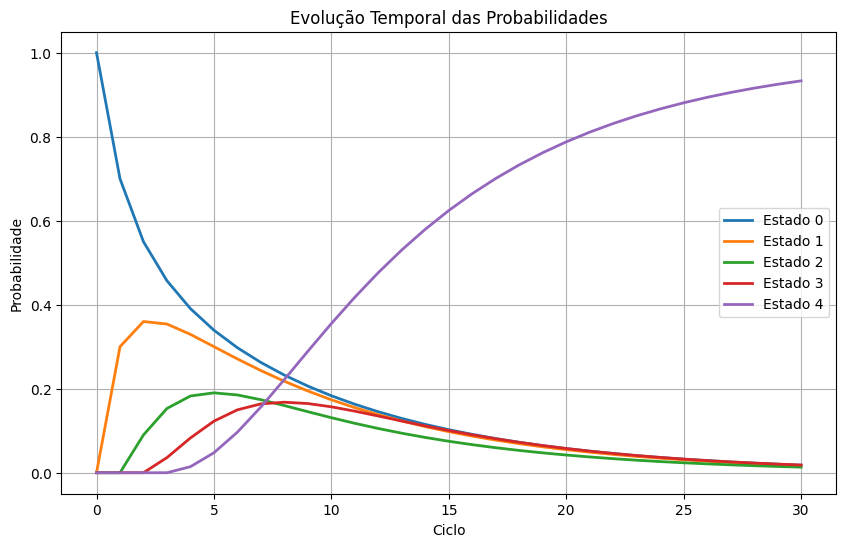


Probabilidade após 30 ciclos:
P(S0) = 0.018127
P(S1) = 0.017307
P(S2) = 0.013281
P(S3) = 0.018257
P(S4) = 0.933028

Probabilidade de falha total (S4):
0.9330279203491627

Matriz Fundamental N:
[[6.1111 4.1667 2.5    2.5   ]
 [2.7778 4.1667 2.5    2.5   ]
 [0.5556 0.8333 2.5    2.5   ]
 [0.     0.     0.     2.5   ]]

Tempo médio até absorção:
Estado 0: 15.2778 ciclos
Estado 1: 11.9444 ciclos
Estado 2: 6.3889 ciclos
Estado 3: 2.5000 ciclos


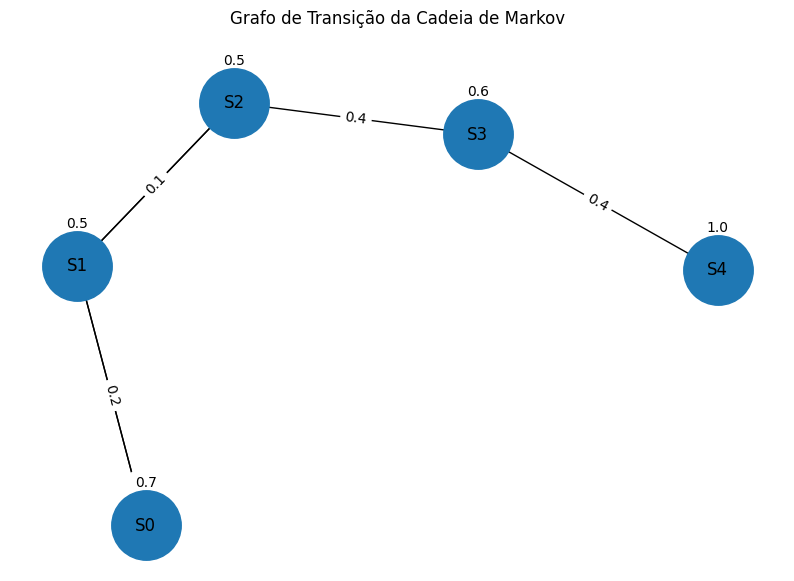


Distribuição após muitos ciclos:
[0. 0. 0. 0. 1.]


In [ ]:
# Matriz de transição

P = np.array([
    [0.7, 0.3, 0.0, 0.0, 0.0],
    [0.2, 0.5, 0.3, 0.0, 0.0],
    [0.0, 0.1, 0.5, 0.4, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.4],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

estados = ['S0','S1','S2','S3','S4']

# Função para simular uma trajetória

def simular_cadeia(P, estado_inicial, n_passos):

  estado = estado_inicial
  trajetoria = [estado]

  for _ in range(n_passos):

    estado = np.random.choice(
        np.arange(len(P)),
        p=P[estado]
    )

    trajetoria.append(estado)

  return trajetoria

# Simulação de uma trajetória

np.random.seed(123)

traj = simular_cadeia(P, estado_inicial=0, n_passos=30)

print("Trajetória simulada:")
print(traj)

# Evolução das Probabilidades

n_ciclos = 30

# estado inicial = S0
pi0 = np.array([1,0,0,0,0])

historico = [pi0]

pi = pi0.copy()

for _ in range(n_ciclos):
  pi = pi @ P
  historico.append(pi)

historico = np.array(historico)

# Probabilidade de estar em cada estado

plt.figure(figsize=(10,6))

for i in range(5):
  plt.plot(
      historico[:,i],
      linewidth=2,
      label=f'Estado {i}'
  )

plt.xlabel('Ciclo')
plt.ylabel('Probabilidade')
plt.title('Evolução Temporal das Probabilidades')
plt.grid(True)
plt.legend()
plt.show()

# Probabilidade de Absorção

print("\nProbabilidade após 30 ciclos:")

for i in range(5):
  print(f"P(S{i}) = {historico[-1,i]:.6f}")

print("\nProbabilidade de falha total (S4):")
print(historico[-1,4])

# Matriz Fundamental

Q = P[:4,:4]

I = np.eye(Q.shape[0])

N = np.linalg.inv(I - Q)

print("\nMatriz Fundamental N:")
print(np.round(N,4))

# Tempo Médio até Absorção

ones = np.ones((4,1))

t = N @ ones

print("\nTempo médio até absorção:")

for i in range(4):
  print(f"Estado {i}: {t[i,0]:.4f} ciclos")

# Grafo de Transições

G = nx.DiGraph()

for i in range(5):
  G.add_node(estados[i])

for i in range(5):
  for j in range(5):

    if P[i,j] > 0:

      G.add_edge(
          estados[i],
          estados[j],
          weight=P[i,j]
      )

plt.figure(figsize=(10,7))

pos = nx.spring_layout(G,seed=42)
nx.draw_networkx_nodes(G,pos,node_size=2500)
nx.draw_networkx_labels(G,pos,font_size=12)
nx.draw_networkx_edges(G,pos,arrows=True,arrowsize=20)

edge_labels = {(u,v): f"{d['weight']:.1f}" for u,v,d in G.edges(data=True)}

nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels)

plt.title("Grafo de Transição da Cadeia de Markov")
plt.axis('off')
plt.show()

# Distribuição estacionária após muitos ciclos

pi_inf = np.array([1,0,0,0,0])

for _ in range(500):
  pi_inf = pi_inf @ P

print("\nDistribuição após muitos ciclos:")
print(np.round(pi_inf,6))